In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [44]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
## Realizando a importação dos dados
## o parâmetro "header" serve para determinar qual linha será o cabeçalho

df_lacto = pd.read_csv("https://raw.githubusercontent.com/arkherim/praticas-iv/refs/heads/main/dados/LactoVisao_Resultado_Mensal.csv", sep=",", encoding="utf-8", header=3)

In [5]:
## Realizando a importação dos dados
## o parâmetro "header" serve para determinar qual linha será o cabeçalho

df_cepea = pd.read_csv("https://raw.githubusercontent.com/arkherim/praticas-iv/refs/heads/main/dados/CEPEA_Plan_1.csv", sep=",", encoding="utf-8", header=3)

## Tratamento de dados do cliente

In [7]:
# Alterar o nome das colunas

df_lacto = df_lacto.rename(columns={
    'Mês/Ano': 'data',
    'Nº Vacas Lactação': 'qtd_vacas',
    'Litros no Mês (L)': 'litros_mes',
    'Preço Unitário (R$/L)': 'preco_unitario',
    'Valor Total Pago (R$)': 'valor_total',
    'Var. Litros vs Mês Anterior (%)': 'variacao_mensal'
})

In [8]:
# Elimina linhas onde o valor_total é Nulo/NaN

df_lacto = df_lacto.dropna(subset=['valor_total'])

In [9]:
# Elimina a última linha do dataframe (linha que contém algumas medidas)

df_lacto = df_lacto.drop((len(df_lacto['valor_total']) - 1))

In [10]:
# Eliminar colunas desnecessárias
# Eliminaremos a variação percentual, pois é um dado que pode ser recalculado depois, se necessário

df_lacto = df_lacto.drop(columns=['variacao_mensal'])

In [11]:
# Garantir que as colunas numéricas estão de fato como float
# Remover pontos de milhar, trocar vírgula por ponto e limpar o 'R$'

df_lacto['litros_mes'] = df_lacto['litros_mes'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

df_lacto['preco_unitario'] = df_lacto['preco_unitario'].astype(str).str.replace('R$', '', regex=False).str.strip().str.replace(',', '.', regex=False).astype(float)

df_lacto['valor_total'] = df_lacto['valor_total'].astype(str).str.replace('R$', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

df_lacto['qtd_vacas'] = df_lacto['qtd_vacas'].astype(int)

In [12]:
# Tratar as datas
# Dicionário para mapear a abreviação do mês em português para número

meses_pt = {'Jan': '01', 'Fev': '02', 'Mar': '03', 'Abr': '04', 'Mai': '05', 'Jun': '06',
            'Jul': '07', 'Ago': '08', 'Set': '09', 'Out': '10', 'Nov': '11', 'Dez': '12'}

In [13]:
# Divide "Set/2024" em mês e ano, mapeia o mês e converte para datetime (sempre dia 01)

df_lacto['mes_num'] = df_lacto['data'].str.split('/').str[0].map(meses_pt)
df_lacto['ano_num'] = df_lacto['data'].str.split('/').str[1]
df_lacto['data'] = pd.to_datetime(df_lacto['ano_num'] + '-' + df_lacto['mes_num'] + '-01')
df_lacto = df_lacto.drop(columns=['mes_num', 'ano_num']) # Remove colunas de apoio

In [14]:
# Tratar valores nulos e ausentes
# Preenche as vacas faltantes com a mediana e deleta linhas que não possuem data

df_lacto['qtd_vacas'] = df_lacto['qtd_vacas'].fillna(df_lacto['qtd_vacas'].median())
df_lacto = df_lacto.dropna(subset=['data'])

In [15]:
# Verificar duplicados

print("Linhas duplicadas em LactoVisão:", df_lacto.duplicated().sum())

Linhas duplicadas em LactoVisão: 0


In [16]:
# Remover possíveis linhas 100% duplicadas

df_lacto = df_lacto.drop_duplicates()

In [17]:
df_lacto.head()

,data,qtd_vacas,litros_mes,preco_unitario,valor_total
0,2024-09-01,23,11178.3,2.441,27286.23
1,2024-10-01,22,11197.4,2.332,26112.34
2,2024-11-01,22,12197.9,2.276,27762.42
3,2024-12-01,22,12281.5,2.252,27657.94
4,2025-01-01,21,11379.3,2.334,26559.29


In [18]:
df_lacto.tail()

,data,qtd_vacas,litros_mes,preco_unitario,valor_total
19,2026-04-01,20,8939.3,2.766,24726.10
20,2026-05-01,19,7959.8,2.870,22844.63
21,2026-06-01,19,7347.8,2.980,21896.44
22,2026-07-01,18,7475.8,2.995,22390.02
23,2026-08-01,18,7633.1,2.937,22418.41


In [19]:
df_lacto.shape

(24, 5)

In [20]:
df_lacto.dtypes

,0
data,datetime64[ns]
qtd_vacas,int64
litros_mes,float64
preco_unitario,float64
valor_total,float64


## Tratamento de dados do CEPEA

In [21]:
# Alterar o nome das colunas

df_cepea = df_cepea.rename(columns={
    'Ano': 'ano',
    'Mês': 'mes_texto',
    'Estado': 'estado',
    'Preço médio': 'preco_medio'
})

In [22]:
# Garantir que as colunas numéricas estão de fato como float

df_cepea['preco_medio'] = df_cepea['preco_medio'].astype(str).str.replace(',', '.', regex=False).astype(float)

In [23]:
# Tratar as datas

meses_cepea = {'JAN': '01', 'FEV': '02', 'MAR': '03', 'ABR': '04', 'MAI': '05', 'JUN': '06',
               'JUL': '07', 'AGO': '08', 'SET': '09', 'OUT': '10', 'NOV': '11', 'DEZ': '12'}

df_cepea['mes_num'] = df_cepea['mes_texto'].map(meses_cepea)

In [24]:
# Consolida em uma única coluna do tipo datetime e deleta as antigas

df_cepea['data'] = pd.to_datetime(df_cepea['ano'].astype(str) + '-' + df_cepea['mes_num'] + '-01')
df_cepea = df_cepea.drop(columns=['ano', 'mes_texto', 'mes_num'])

In [25]:
# Tratar valores nulos e ausentes

df_cepea = df_cepea.dropna(subset=['preco_medio', 'data'])

In [26]:
# Verificar duplicados

print("Linhas duplicadas no CEPEA:", df_cepea.duplicated().sum())

Linhas duplicadas no CEPEA: 0


In [27]:
# Remover duplicados

df_cepea = df_cepea.drop_duplicates()

In [28]:
df_cepea.head()

,estado,preco_medio,data
0,RS,0.48,2004-12-01
1,PR,0.48,2004-12-01
2,SP,0.51,2004-12-01
3,MG,0.49,2004-12-01
4,GO,0.49,2004-12-01


In [29]:
df_cepea.tail()

,estado,preco_medio,data
2770,GO,2.94,2026-07-01
2771,BA,2.67,2026-07-01
2772,BRASIL,2.88,2026-07-01
2773,ES,2.73,2026-07-01
2774,RJ,2.72,2026-07-01


In [30]:
df_cepea.shape

(2775, 3)

In [31]:
df_cepea.dtypes

,0
estado,object
preco_medio,float64
data,datetime64[ns]


## União dos dois dataframes

In [32]:
# Filtrar o DataFrame do CEPEA mantendo apenas BRASIL e SC

df_cepea_filtrado = df_cepea[df_cepea['estado'].isin(['BRASIL', 'SC'])]

In [33]:
# Reestruturar (Pivotar) os dados do CEPEA
# Isso vai pegar as linhas de 'estado' e transformá-las em colunas onde os valores serão o 'preco_medio'

df_cepea_pivot = df_cepea_filtrado.pivot_table(
    index='data',
    columns='estado',
    values='preco_medio'
).reset_index()

In [34]:
# Limpar o nome do eixo das colunas e renomeá-las para ficar mais claro

df_cepea_pivot.columns.name = None
df_cepea_pivot = df_cepea_pivot.rename(columns={
    'BRASIL': 'preco_cepea_brasil',
    'SC': 'preco_cepea_sc'
})

In [35]:
# Unir os dois DataFrames
# Utiliza a cláusula 'how="left"' para manter TODAS as linhas da LactoVisão
# e trazer os preços do CEPEA onde as datas (mês/ano) baterem.

df_final = pd.merge(df_lacto, df_cepea_pivot, on='data', how='left')

In [36]:
# Visualizar o resultado

df_final.head()

,data,qtd_vacas,litros_mes,preco_unitario,valor_total,preco_cepea_brasil,preco_cepea_sc
0,2024-09-01,23,11178.3,2.441,27286.23,2.87,2.81
1,2024-10-01,22,11197.4,2.332,26112.34,2.81,2.77
2,2024-11-01,22,12197.9,2.276,27762.42,2.64,2.58
3,2024-12-01,22,12281.5,2.252,27657.94,2.58,2.49
4,2025-01-01,21,11379.3,2.334,26559.29,2.65,2.55


In [37]:
df_final.tail()

,data,qtd_vacas,litros_mes,preco_unitario,valor_total,preco_cepea_brasil,preco_cepea_sc
19,2026-04-01,20,8939.3,2.766,24726.10,2.66,2.69
20,2026-05-01,19,7959.8,2.870,22844.63,2.66,2.63
21,2026-06-01,19,7347.8,2.980,21896.44,2.75,2.71
22,2026-07-01,18,7475.8,2.995,22390.02,2.88,2.79
23,2026-08-01,18,7633.1,2.937,22418.41,NaN,NaN


In [38]:
df_final.shape

(24, 7)

## EDA - Análise Exploratória de Dados inicial

In [39]:
# Configura o estilo visual dos gráficos

sns.set_theme(style="whitegrid", context="talk")

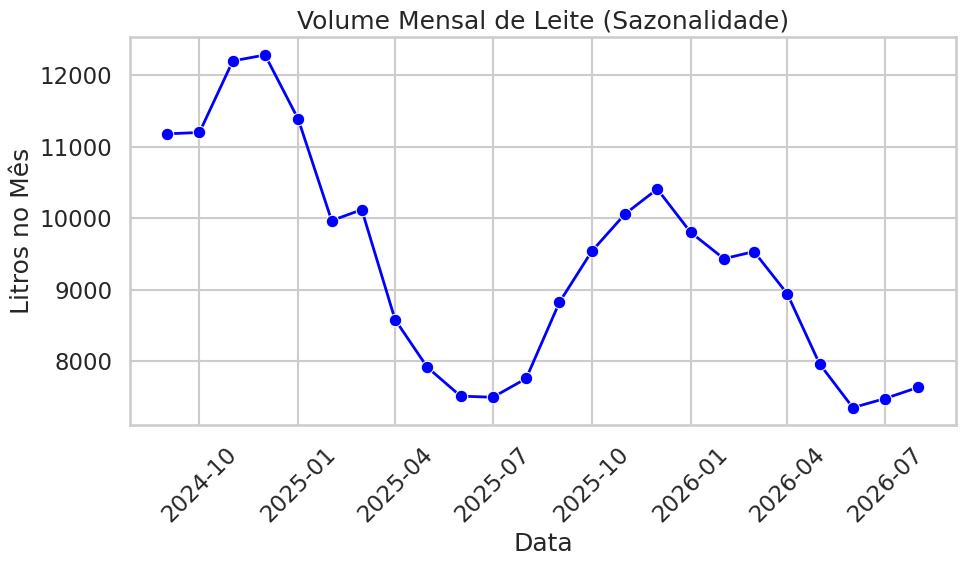

In [40]:
# Gráfico 1: Volume Mensal de Leite (Sazonalidade)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_final, x='data', y='litros_mes', marker='o', color='blue', linewidth=2)
plt.title('Volume Mensal de Leite (Sazonalidade)')
plt.ylabel('Litros no Mês')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

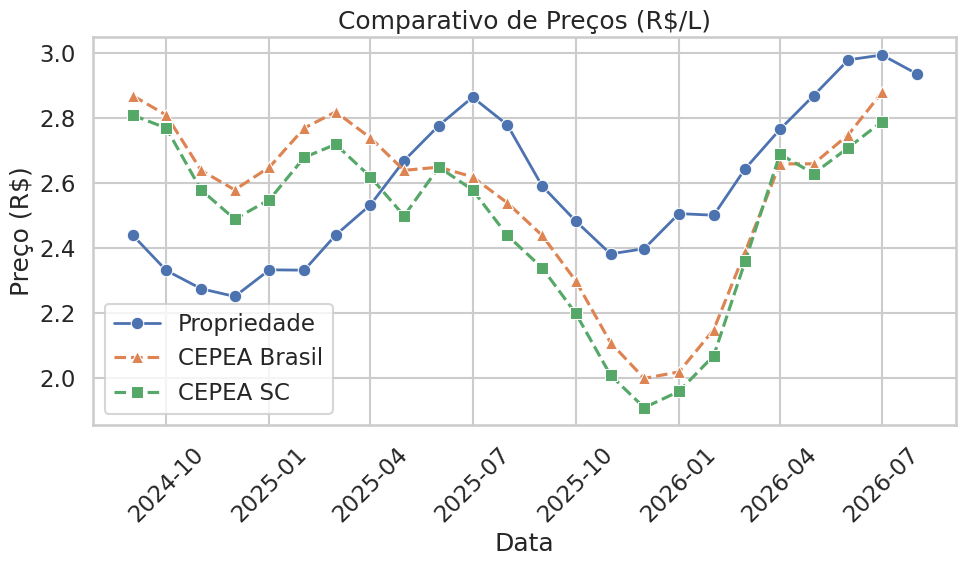

In [41]:
# Gráfico 2: Comparativo de Preços

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_final, x='data', y='preco_unitario', marker='o', label='Propriedade', linewidth=2)
sns.lineplot(data=df_final, x='data', y='preco_cepea_brasil', marker='^', label='CEPEA Brasil', linestyle='--')
sns.lineplot(data=df_final, x='data', y='preco_cepea_sc', marker='s', label='CEPEA SC', linestyle='--')
plt.title('Comparativo de Preços (R$/L)')
plt.ylabel('Preço (R$)')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

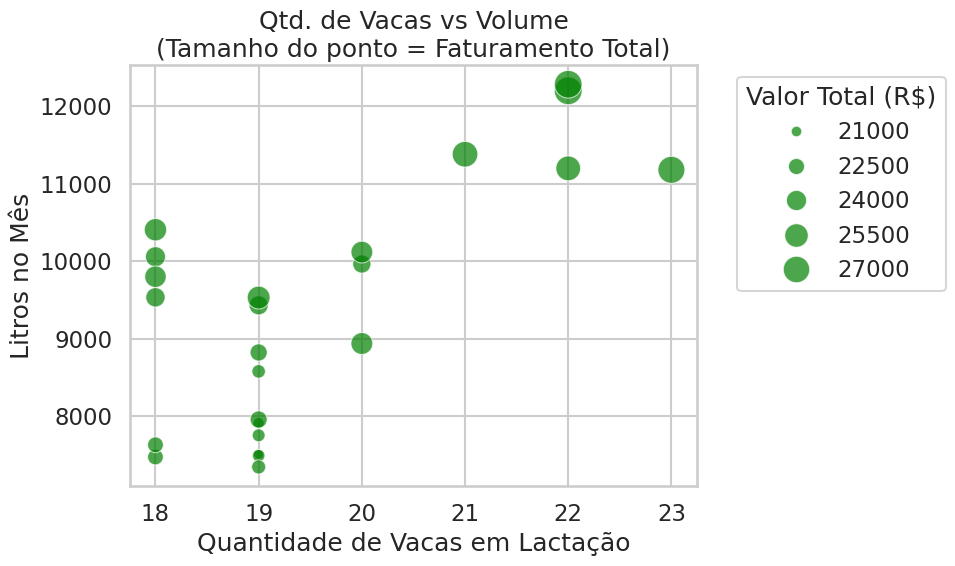

In [42]:
# Gráfico 3: Relação entre Vacas, Volume e Faturamento

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='qtd_vacas', y='litros_mes', size='valor_total', sizes=(50, 400), alpha=0.7, color='green')
plt.title('Qtd. de Vacas vs Volume\n(Tamanho do ponto = Faturamento Total)')
plt.ylabel('Litros no Mês')
plt.xlabel('Quantidade de Vacas em Lactação')
# Coloca a legenda fora do gráfico para não sobrepor as bolhas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Valor Total (R$)')
plt.tight_layout()
plt.show()

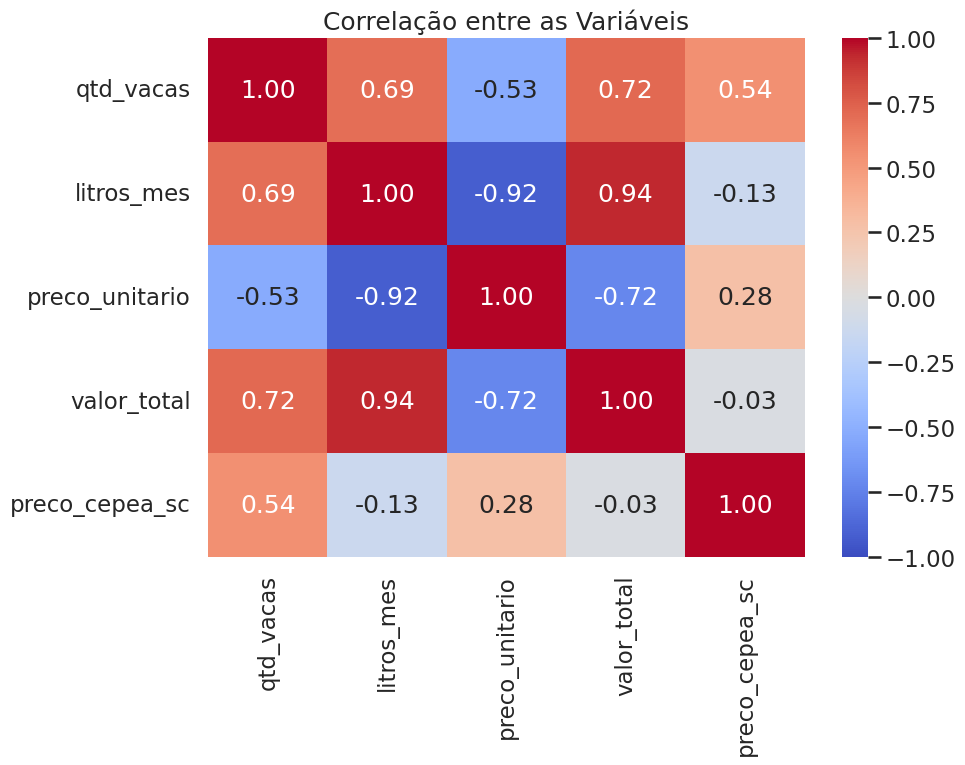

In [43]:
# Gráfico 4: Matriz de Correlação

plt.figure(figsize=(10, 8))
corr = df_final[['qtd_vacas', 'litros_mes', 'preco_unitario', 'valor_total', 'preco_cepea_sc']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação entre as Variáveis')
plt.tight_layout()
plt.show()

## Exportação dos dados tratados

In [45]:
# Define o nome do arquivo que será criado

nome_arquivo = 'Dataset_Tratado.csv'

In [46]:
# Exporta o DataFrame final para um arquivo CSV

df_final.to_csv(nome_arquivo, index=False, encoding='utf-8')

# O parâmetro 'index=False' evita que os números das linhas (0, 1, 2...) sejam salvos como uma coluna extra

print(f"Arquivo '{nome_arquivo}' gerado com sucesso!")

Arquivo 'Dataset_Tratado.csv' gerado com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Aciona o download do arquivo de dados tratado
files.download(nome_arquivo)